In [1]:
# 第4章｜實做神經網路大盤策略：每次開啟 notebook，先執行這一格（安裝套件、登入 FinLab、開啟資料快取）
%pip install -q finlab==2.0.21 ta-lib==0.8.1
import finlab
from finlab import data

finlab.login()
data.set_storage(data.FileStorage())

Note: you may need to restart the kernel to use updated packages.


已登入（使用快取憑證）。


In [2]:
QUICK_RUN = False  # True：只訓練少量 epoch，只用來快速檢查程式能不能跑

# 實做神經網路（NN）大盤策略

**對應影片**：第 4 章 單元 2「實做 NN 大盤策略」（觀念請看單元 1「NN」）

**和影片的差異**

| 影片（2018） | 新版教材 |
| --- | --- |
| 大盤 15 分 K、`from tensorflow import keras` 的舊版 Keras | 加權指數日 K、Keras 3（Colab 內建）：`import keras` |
| `layers.Dense(..., input_shape=...)` | 先寫 `keras.Input(shape=...)` 再接各層 |
| 標準化用全部資料計算 | 標準化只用訓練資料計算，避免偷看未來 |
| 報酬用指數點數相加 | 預測「買進 0050、持有 10 天」，用 `sim()` 回測 |

特徵與答案和第 3 章「技術指標機器學習策略」相同，只是把 LightGBM 換成神經網路。

In [3]:
import keras
import pandas as pd
import talib
import finlab.ml.label as label
from finlab.backtest import sim
from keras import layers
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

TRADE_STOCK = '0050'
ETF_TAX_RATIO = 0.001
HORIZON = 10
TRAIN_END = '2015-12-31'
TEST_START = '2016-01-01'
RANDOM_STATE = 0

keras.utils.set_random_seed(RANDOM_STATE)

## 1. 特徵與答案

In [4]:
PERIODS = [5, 10, 20, 60, 120]
STOCH_SMOOTHING = 3

taiex = pd.DataFrame({
    field: data.get(f'taiex_total_index:{name}')['TAIEX']
    for field, name in [('open', '開盤指數'), ('high', '最高指數'), ('low', '最低指數'), ('close', '收盤指數')]
}).dropna()


def technical_features(ohlc: pd.DataFrame) -> pd.DataFrame:
    high, low, close = ohlc['high'], ohlc['low'], ohlc['close']
    features = {}
    for period in PERIODS:
        slowk, slowd = talib.STOCH(high, low, close, fastk_period=period,
                                   slowk_period=STOCH_SMOOTHING, slowd_period=STOCH_SMOOTHING)
        features[f'rsi_{period}'] = talib.RSI(close, timeperiod=period)
        features[f'k_{period}'] = slowk
        features[f'd_{period}'] = slowd
        features[f'willr_{period}'] = talib.WILLR(high, low, close, timeperiod=period)
        features[f'cci_{period}'] = talib.CCI(high, low, close, timeperiod=period)
        features[f'roc_{period}'] = talib.ROC(close, timeperiod=period)
        features[f'sma_bias_{period}'] = close / talib.SMA(close, timeperiod=period)
        features[f'wma_bias_{period}'] = close / talib.WMA(close, timeperiod=period)
        features[f'atr_ratio_{period}'] = talib.ATR(high, low, close, timeperiod=period) / close
    macd, macd_signal, macd_hist = talib.MACD(close)
    features['macd'] = macd / close
    features['macd_signal'] = macd_signal / close
    features['macd_hist'] = macd_hist / close
    return pd.DataFrame(features)


def forward_return(dates: pd.DatetimeIndex, period: int) -> pd.Series:
    index = pd.MultiIndex.from_product([dates, [TRADE_STOCK]], names=['datetime', 'instrument'])
    return label.return_percentage(index, period=period).droplevel('instrument')


features = technical_features(taiex)
feature_names = list(features.columns)
dataset = features.assign(future_return=forward_return(features.index, HORIZON)).dropna()
dataset['up'] = dataset['future_return'] > 0

train, test = dataset.loc[:TRAIN_END], dataset.loc[TEST_START:]
print(f'訓練 {len(train)} 天、測試 {len(test)} 天、{len(feature_names)} 個特徵')

訓練 2162 天、測試 726 天、48 個特徵


## 2. 標準化

神經網路對特徵的尺度很敏感（RSI 是 0～100、乖離率在 1 附近），要先轉成平均 0、標準差 1。

In [5]:
scaler = StandardScaler().fit(train[feature_names])
X_train = scaler.transform(train[feature_names])
X_test = scaler.transform(test[feature_names])
y_train, y_test = train['up'].to_numpy(), test['up'].to_numpy()

pd.DataFrame(X_train, columns=feature_names).describe().loc[['mean', 'std']].round(2)

,rsi_5,k_5,d_5,willr_5,cci_5,roc_5,sma_bias_5,wma_bias_5,atr_ratio_5,rsi_10,...,d_120,willr_120,cci_120,roc_120,sma_bias_120,wma_bias_120,atr_ratio_120,macd,macd_signal,macd_hist
mean,0.0,-0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0,-0.0,0.0,...,0.0,-0.0,0.0,0.0,-0.0,-0.0,0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 3. 建立神經網路

一層 100 個神經元的隱藏層（ReLU），輸出層 1 個神經元（sigmoid），輸出「上漲的機率」。

In [6]:
HIDDEN_UNITS = 100

model = keras.Sequential([
    keras.Input(shape=(len(feature_names),)),
    layers.Dense(HIDDEN_UNITS, activation='relu'),
    layers.Dense(1, activation='sigmoid'),
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[keras.metrics.AUC(name='auc')])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │         4,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,001 (19.54 KB)

 Trainable params: 5,001 (19.54 KB)

 Non-trainable params: 0 (0.00 B)

## 4. 訓練

- `epochs`：把全部訓練資料看過幾遍。
- `batch_size`：每看幾筆資料更新一次權重。

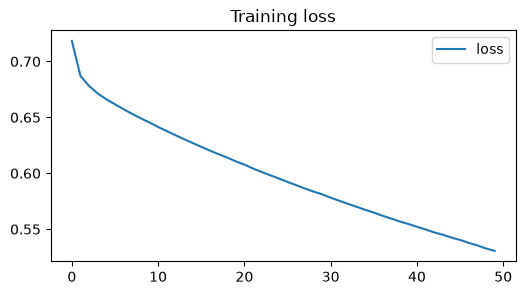

In [7]:
EPOCHS = 2 if QUICK_RUN else 50
BATCH_SIZE = 64

history = model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
pd.DataFrame(history.history)[['loss']].plot(figsize=(6, 3), title='Training loss');

In [8]:
train_probability = pd.Series(model.predict(X_train, verbose=0).ravel(), index=train.index)
test_probability = pd.Series(model.predict(X_test, verbose=0).ravel(), index=test.index)
print(f'訓練 AUC：{roc_auc_score(y_train, train_probability):.3f}')
print(f'測試 AUC：{roc_auc_score(y_test, test_probability):.3f}')

訓練 AUC：0.830
測試 AUC：0.470


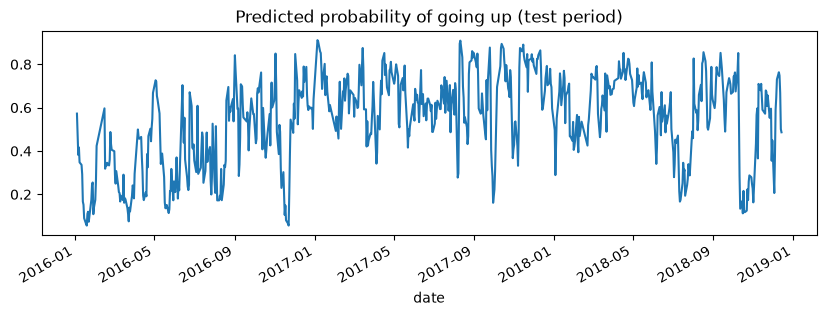

In [9]:
test_probability.plot(figsize=(10, 3), title='Predicted probability of going up (test period)');

## 5. 回測

和第 3 章相同的規則：機率高於訓練期間第 70 百分位就買進，持有 `HORIZON` 天。

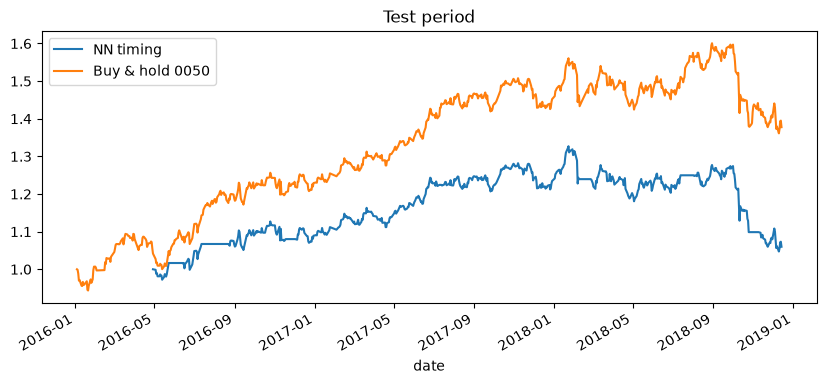

In [10]:
SIGNAL_QUANTILE = 0.7

threshold = train_probability.quantile(SIGNAL_QUANTILE)
hold = (test_probability > threshold).rolling(HORIZON, min_periods=1).max().astype(bool)
position = hold.to_frame(TRADE_STOCK)

strategy = sim(position, name='NN timing', tax_ratio=ETF_TAX_RATIO)
buy_and_hold = sim(position.notna(), name='Buy & hold 0050', tax_ratio=ETF_TAX_RATIO)

pd.DataFrame({'NN timing': strategy.creturn, 'Buy & hold 0050': buy_and_hold.creturn}).plot(
    figsize=(10, 4), title='Test period');

In [11]:
pd.DataFrame({
    name: {key: report.get_stats()[key] for key in ['cagr', 'max_drawdown', 'daily_sharpe']}
    for name, report in [('NN timing', strategy), ('Buy & hold 0050', buy_and_hold)]
}).T.style.format({'cagr': '{:.2%}', 'max_drawdown': '{:.2%}', 'daily_sharpe': '{:.2f}'})

,cagr,max_drawdown,daily_sharpe
NN timing,2.24%,-21.09%,0.09
Buy & hold 0050,11.50%,-14.96%,0.72


訓練 AUC 比測試 AUC 高很多，就是「過度擬合」。下一個單元學習怎麼用驗證資料、Dropout、Early Stopping 改善。